In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
from pathlib import Path

yields_csv_dir = Path("Bond_Research") / "yields_csv"

files = {
    "Germany": "bund_uniform.csv",
    "Austria": "austria_uniform.csv",
    "Belgium": "belgium_uniform.csv",
    "France": "france_uniform.csv",
    "Ireland": "ireland_uniform.csv",
    "Italy": "italy_uniform.csv",
    "Netherlands": "netherlands_uniform.csv",
    "Portugal": "portugal_uniform.csv",
    "Spain": "spain_uniform.csv",
    "Greece": "greece_uniform.csv"
}

dfs = []

for country, file in files.items():

    temp = pd.read_csv(yields_csv_dir / file)

    temp["Country"] = country

    dfs.append(temp)

bond_df = pd.concat(dfs, ignore_index=True)

In [3]:
bond_df = bond_df[
    ["Date", "Country", "Maturity", "Yield"]
]

bond_df["Date"] = pd.to_datetime(
    bond_df["Date"],
    format="mixed"
)

bond_df["Yield"] = pd.to_numeric(
    bond_df["Yield"],
    errors="coerce"
)

In [4]:
bund = (
    bond_df[
        bond_df["Country"] == "Germany"
    ]
    [["Date", "Maturity", "Yield"]]
    .rename(
        columns={"Yield": "BundYield"}
    )
)
bund.head()

,Date,Maturity,BundYield
0,2026-09-25,2Y,3.274
1,2026-09-25,5Y,3.409
2,2026-09-25,10Y,3.600
3,2026-09-24,2Y,3.321
4,2026-09-24,5Y,3.437


In [5]:
bond_df = bond_df.merge(
    bund,
    on=["Date", "Maturity"],
    how="left"
)

In [6]:
bond_df["Spread"] = (
    bond_df["Yield"]
    - bond_df["BundYield"]
)
bond_df.info()
bond_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 216415 entries, 0 to 216414
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       216415 non-null  datetime64[us]
 1   Country    216415 non-null  str           
 2   Maturity   216415 non-null  str           
 3   Yield      207940 non-null  float64       
 4   BundYield  212617 non-null  float64       
 5   Spread     204280 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 11.8 MB


,Date,Yield,BundYield,Spread
count,216415,207940.000000,212617.000000,204280.000000
mean,2012-11-07 12:43:04.833768,3.755845,1.970035,1.846651
min,1999-01-01 00:00:00,-1.014000,-1.014000,-1.308000
25%,2005-12-05 00:00:00,0.833000,0.171000,0.043000
50%,2012-11-07 00:00:00,2.807000,2.242000,0.217000
75%,2019-10-11 00:00:00,4.041000,3.463000,0.666000
max,2026-09-25 00:00:00,230.370000,5.644000,230.222000
std,NaN,13.625375,1.810887,13.594149


In [7]:
bond_df.loc[
    bond_df["Yield"].idxmax()
]

Date         2012-03-07 00:00:00
Country                   Greece
Maturity                      2Y
Yield                     230.37
BundYield                  0.148
Spread                   230.222
Name: 205048, dtype: object

note that greece is responsible for the largest spread. probably related to the Greek financial crisis.

# EDA (excluding Greece)

In [8]:
eda_df = bond_df[
    bond_df["Country"] != "Greece"
].copy()

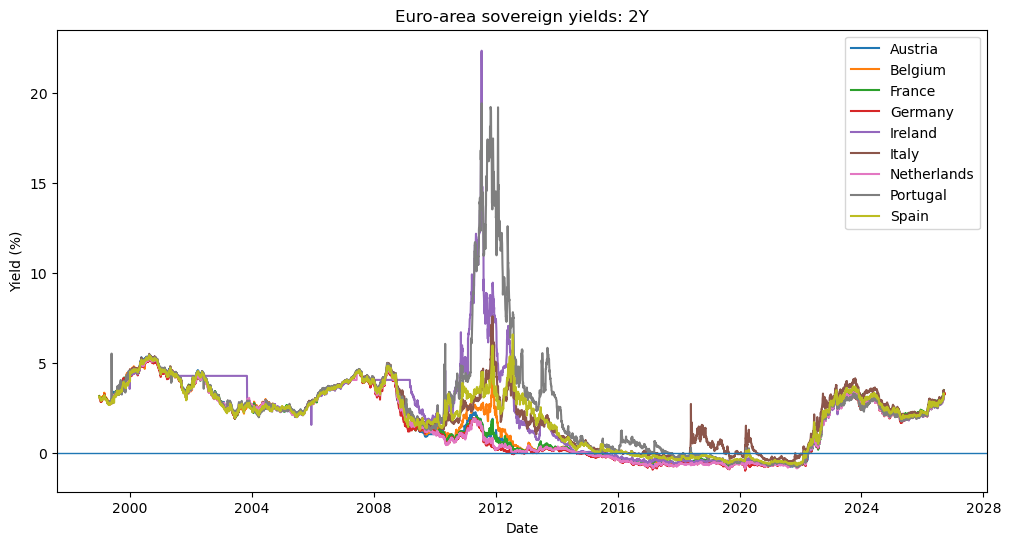

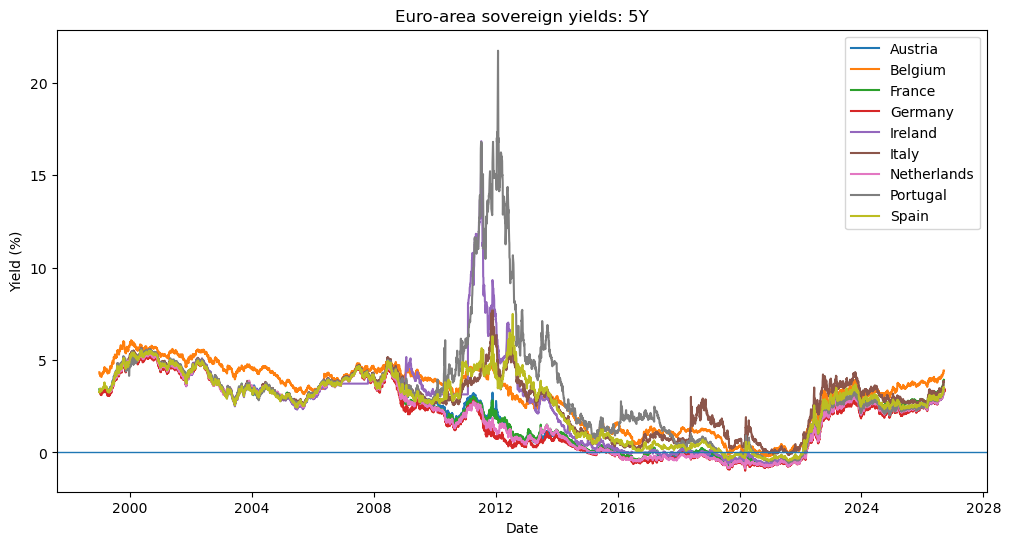

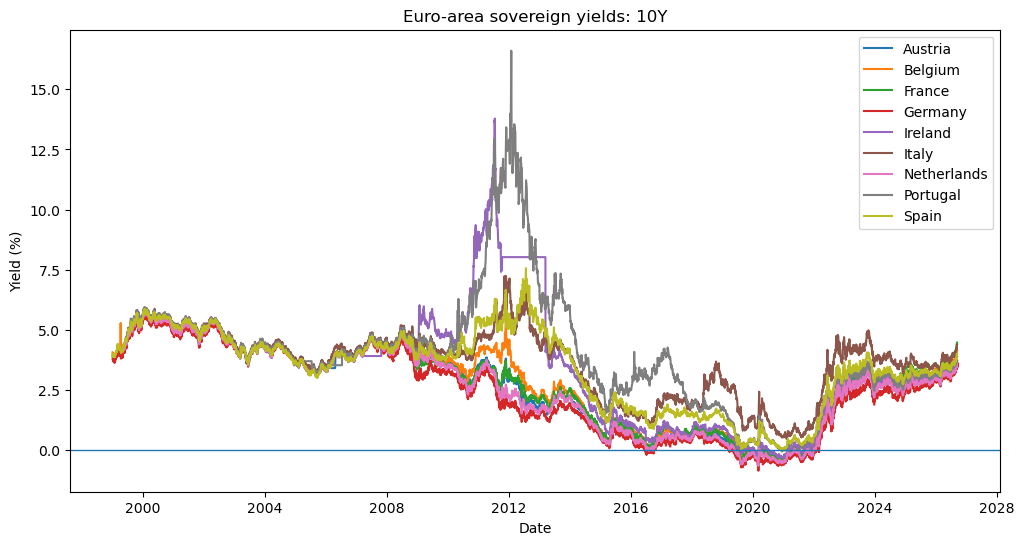

In [9]:
import matplotlib.pyplot as plt

for maturity in ["2Y", "5Y", "10Y"]:
    temp = eda_df[eda_df["Maturity"] == maturity]

    pivot = temp.pivot(
        index="Date",
        columns="Country",
        values="Yield"
    )

    plt.figure(figsize=(12, 6))

    for country in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[country],
            label=country
        )

    plt.axhline(0, linewidth=1)
    plt.title(f"Euro-area sovereign yields: {maturity}")
    plt.xlabel("Date")
    plt.ylabel("Yield (%)")
    plt.legend()
    plt.show()

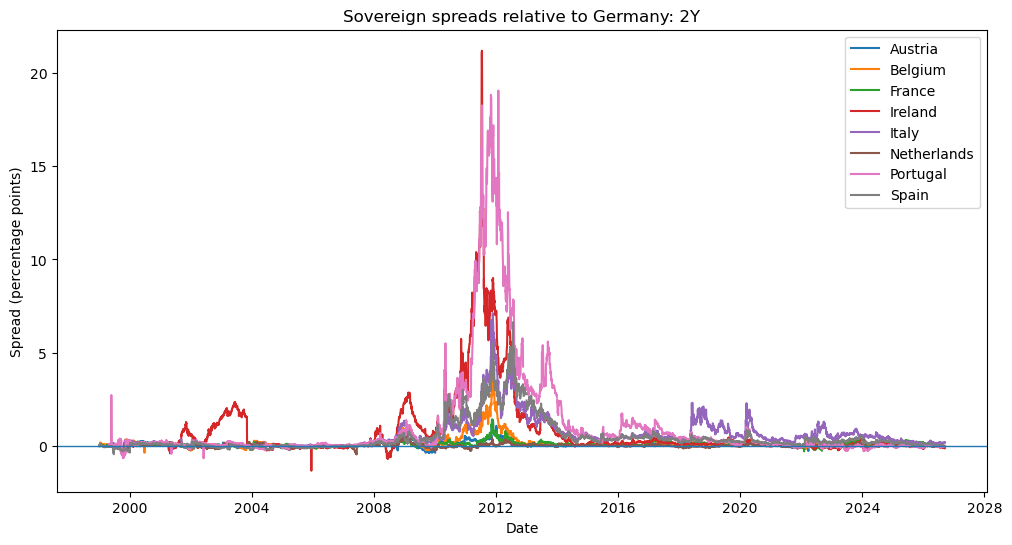

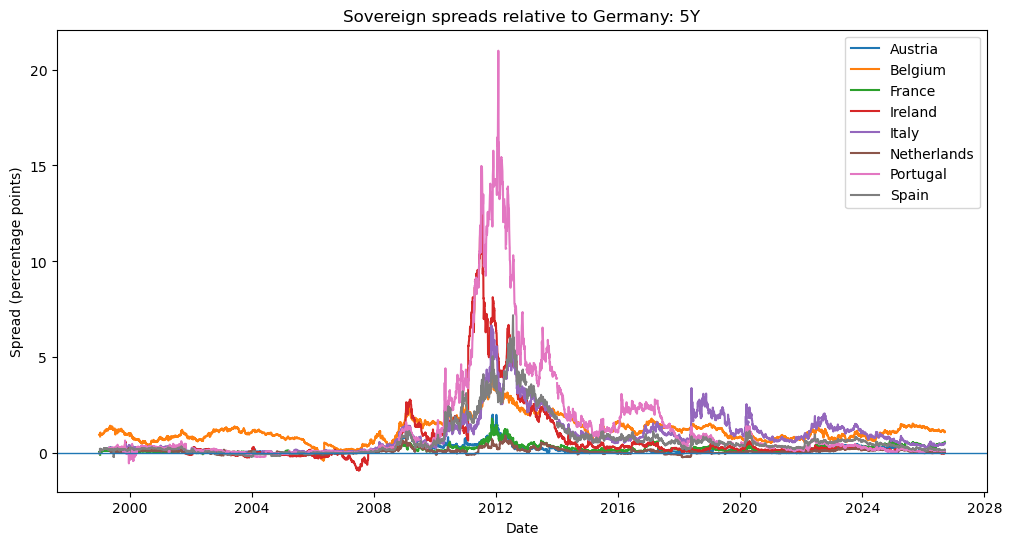

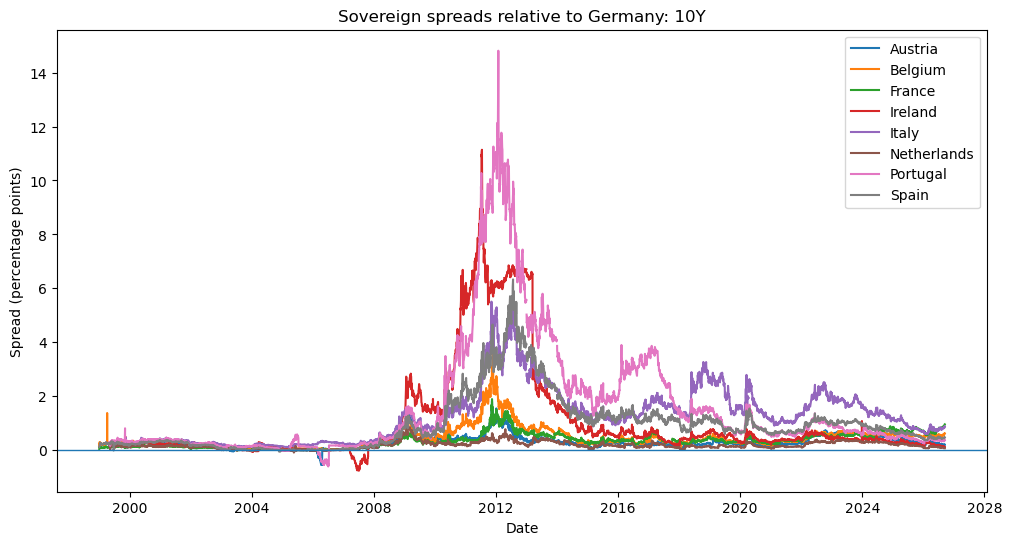

In [10]:
spread_df = eda_df[
    eda_df["Country"] != "Germany"
].copy()

for maturity in ["2Y", "5Y", "10Y"]:
    temp = spread_df[
        spread_df["Maturity"] == maturity
    ]

    pivot = temp.pivot(
        index="Date",
        columns="Country",
        values="Spread"
    )

    plt.figure(figsize=(12, 6))

    for country in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[country],
            label=country
        )

    plt.axhline(0, linewidth=1)

    plt.title(
        f"Sovereign spreads relative to Germany: {maturity}"
    )
    plt.xlabel("Date")
    plt.ylabel("Spread (percentage points)")
    plt.legend()
    plt.show()

In [11]:
summary = (
    bond_df
    .groupby(["Country", "Maturity"])
    ["Yield"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)

summary

count       mean        std    min  median      max
Country     Maturity                                                     
Austria     10Y        7140   2.710503   1.743961 -0.485  3.0355    5.879
            2Y         7140   1.651303   1.795707 -0.865  1.9610    5.442
            5Y         7140   2.112692   1.807652 -0.758  2.5385    5.602
Belgium     10Y        7227   2.880024   1.726939 -0.436  3.2850    5.923
            2Y         7227   1.728707   1.774505 -0.833  2.1270    5.387
            5Y         7227   3.129382   1.671640 -0.214  3.4920    6.076
France      10Y        7227   2.772468   1.661648 -0.439  3.1940    5.758
            2Y         7227   1.671014   1.761380 -0.837  1.9250    5.352
            5Y         7227   2.138194   1.735432 -0.798  2.6030    5.427
Germany     10Y        7098   2.430355   1.754862 -0.858  2.6060    5.644
            2Y         7091   1.566449   1.778564 -1.014  1.8240    5.300
            5Y         7097   1.917713   1.792907 -0.991  2.2600    5.278
Greece      10Y        5097   6.683144   5.834408  0.534  4.6290   33.702
            2Y         5097  39.800942  75.402701 -0.533  3.3360  230.370
            5Y         5097  11.790440  16.385459 -0.251  4.1180   57.371
Ireland     10Y        7010   3.430631   2.370873 -0.334  3.4615   13.786
            2Y         7010   2.295327   2.398676 -0.743  2.3465   22.362
            5Y         7010   2.612691   2.264901 -0.660  2.8395   16.849
Italy       10Y        7010   3.617372   1.413001  0.455  3.9715    7.244
            2Y         7010   2.135019   1.631839 -0.521  2.2945    7.583
            5Y         7010   2.838963   1.551857 -0.126  3.1020    7.703
Netherlands 10Y        7140   2.594411   1.744227 -0.652  2.8180    5.816
            2Y         7140   1.578719   1.786364 -0.901  1.8270    5.345
            5Y         7140   2.006171   1.801075 -0.868  2.3625    5.455
Portugal    10Y        7140   3.991844   2.363639 -0.059  3.7585   16.605
            2Y         7140   2.630978   2.842102 -0.814  2.4910   19.436
            5Y         7140   3.354110   2.861599 -0.546  3.0350   21.748
Spain       10Y        7227   3.367445   1.618380 -0.019  3.7330    7.566
            2Y         7227   2.052623   1.678131 -0.694  2.3680    6.571
            5Y         7227   2.639277   1.704640 -0.457  2.9910    7.498

In [12]:
spread_summary = (
    bond_df[
        bond_df["Country"] != "Germany"
    ]
    .groupby(["Country", "Maturity"])
    ["Spread"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)

spread_summary

count       mean        std    min  median      max
Country     Maturity                                                     
Austria     10Y        7003   0.298925   0.236918 -0.545   0.255    1.808
            2Y         6996   0.104138   0.152843 -0.358   0.072    1.420
            5Y         7003   0.212066   0.232783 -0.149   0.160    2.010
Belgium     10Y        7089   0.451107   0.392202 -0.035   0.352    3.554
            2Y         7082   0.165446   0.350954 -0.345   0.084    4.533
            5Y         7088   1.213610   0.637568 -0.383   1.125    4.532
France      10Y        7089   0.343006   0.266010 -0.014   0.317    1.892
            2Y         7082   0.107500   0.132348 -0.270   0.080    1.448
            5Y         7088   0.221616   0.213145 -0.078   0.169    1.809
Greece      10Y        4998   5.059688   5.863220  0.200   2.648   31.903
            2Y         4991  38.623553  75.432175 -0.313   1.807  230.222
            5Y         4998  10.672767  16.664517  0.097   2.420   56.602
Ireland     10Y        6873   1.064227   1.826609 -0.766   0.397   11.140
            2Y         6866   0.782582   1.840065 -1.308   0.127   21.173
            5Y         6873   0.754221   1.678714 -0.907   0.230   14.939
Italy       10Y        6873   1.249206   0.988913  0.035   1.166    5.507
            2Y         6866   0.619977   0.813473 -0.177   0.397    7.127
            5Y         6873   0.979472   1.008626 -0.065   0.741    6.664
Netherlands 10Y        7003   0.182490   0.131897 -0.094   0.154    0.865
            2Y         6996   0.031514   0.089549 -0.433   0.028    0.500
            5Y         7003   0.105580   0.135723 -0.214   0.079    0.930
Portugal    10Y        7003   1.582568   2.223288 -0.608   0.666   14.814
            2Y         6996   1.084519   2.679800 -0.642   0.181   19.040
            5Y         7003   1.457363   2.780376 -0.524   0.384   20.979
Spain       10Y        7089   0.938496   1.009601 -0.059   0.715    6.331
            2Y         7082   0.486875   0.845640 -0.423   0.221    6.643
            5Y         7088   0.723737   1.013809 -0.195   0.421    7.196